# Ergodic Trajectory for enviornments with non-unfiorm traget clarities in different sections

In [1]:
import Pkg; Pkg.activate(""); Pkg.instantiate()

  Activating project at `~/Documents/adaptive-ocean-exploration-sim`


In [2]:
using Logging: global_logger
using TerminalLoggers: TerminalLogger
global_logger(TerminalLogger())

using ProgressLogging

In [3]:
using Plots, Revise, StaticArrays, Interpolations, LinearAlgebra

In [4]:
include("src/kf.jl")
include("src/ngpkf.jl")
include("src/SyntheticData.jl")
include("src/ergodic.jl")
include("src/SOC_Controller.jl")
include("src/simulator_spatial.jl")

Main.SimulatorSpatial

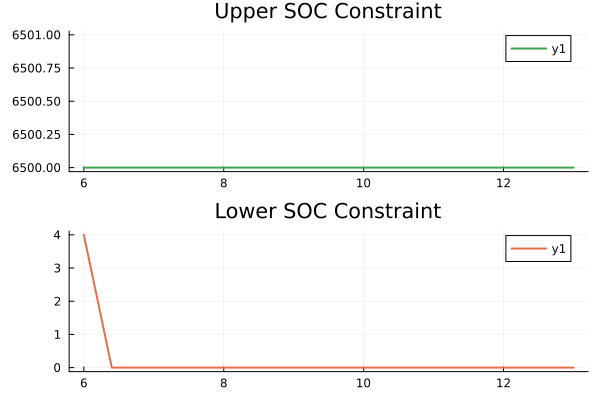

In [5]:
Δt = 0.1; # time step in hours
t = 6:Δt:13;
og_time = t;

lcbf = SoCController.compute_lcbf(t, Δt);
ucbf = SoCController.compute_ucbf(t, Δt);


l = @layout[a;b]
plot(
    plot(og_time, ucbf, title="Upper SOC Constraint", color=3, lw=2),
    plot(og_time, lcbf, title="Lower SOC Constraint", color=2, lw=2),
    layout=l,
)

# # plot(og_time, [ucbf, lcbf], layout=(2,1), label=false, title=["Upper Constraint", "Lower Constraint"])
# xlabel!("Mission Time [hr, 12 = noon]");
# ylabel!("State of Charge [Wh]");
# plot!(legend=false, dpi=1200)

In [6]:
b = SoCController.generate_SOC_target(lcbf, ucbf,  3000, 1000, t, Δt);

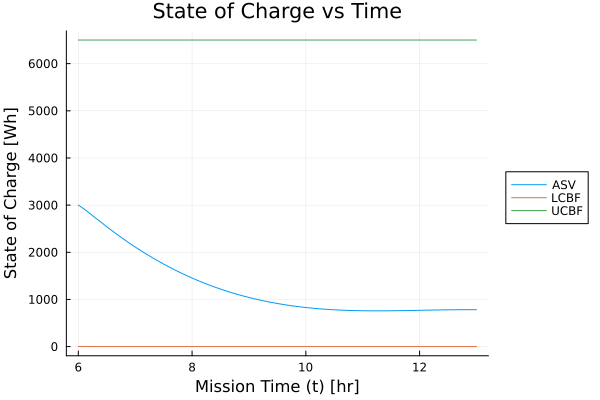

In [7]:
# Plot SOC vs Time
plot(og_time, b, label="ASV");
plot!(og_time, lcbf, label="LCBF");
plot!(og_time, ucbf, label="UCBF");
xlabel!("Mission Time (t) [hr]");
ylabel!("State of Charge [Wh]");
title!("State of Charge vs Time");
plot!(legend=:outerright)

In [8]:
v = SoCController.generate_vel_profile(lcbf, ucbf, b, t, Δt);

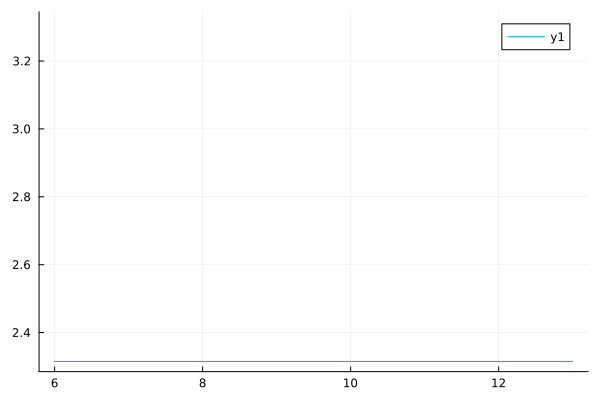

In [9]:
plot(og_time, v)

In [10]:
times = 0:6:180
v_itp = interpolate((times,), v, Gridded(Linear()));

DimensionMismatch: DimensionMismatch: knot vectors must have the same axes as the corresponding dimension of the array

## Spatial-only Matern-12 Kernel

In [11]:
# Define domain vars
dim = 100; # number of data points along each axis in the domain (defining a square domain)
xstart, xstop = 0, 25; # x-axis start and end positions
ystart, ystop = 0, 10; # y-axis start and end positions

σ_sq = 1.0
λₓ = 1/(4.0) 

env_data = SyntheticData.matern12_spatial(dim, xstart, xstop, ystart, ystop, σ_sq, λₓ);
# heatmap(range(xstart, stop=xstop, length=dim), range(ystart, stop=ystop, length=dim), env_data; c = :vik)
# title!("Synthetic Data: σ² = $(σ_sq), λₓ = $(λₓ)")

Main.SyntheticData.EnvDataSpatial{Vector{Float64}, Matrix{Float64}, Interpolations.Extrapolation{Float64, 2, Interpolations.GriddedInterpolation{Float64, 2, Matrix{Float64}, Gridded{Linear{Throw{OnGrid}}}, Tuple{Vector{Float64}, Vector{Float64}}}, Gridded{Linear{Throw{OnGrid}}}, Throw{Nothing}}}([0.0, 0.25252525252525254, 0.5050505050505051, 0.7575757575757576, 1.0101010101010102, 1.2626262626262625, 1.5151515151515151, 1.7676767676767677, 2.0202020202020203, 2.272727272727273  …  22.727272727272727, 22.97979797979798, 23.232323232323232, 23.484848484848484, 23.737373737373737, 23.98989898989899, 24.242424242424242, 24.494949494949495, 24.747474747474747, 25.0], [0.0, 0.10101010101010101, 0.20202020202020202, 0.30303030303030304, 0.40404040404040403, 0.5050505050505051, 0.6060606060606061, 0.7070707070707071, 0.8080808080808081, 0.9090909090909091  …  9.090909090909092, 9.191919191919192, 9.292929292929292, 9.393939393939394, 9.494949494949495, 9.595959595959595, 9.696969696969697, 9.7

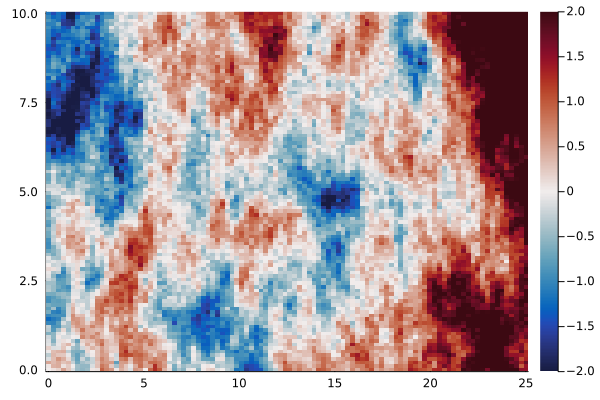

In [12]:
# plotly();
heatmap(env_data.X, env_data.Y, env_data.W', cmap = :balance; plottype=:wx)
plot!(clims=(-2,2))

In [13]:
# Create an ngpkf grid based on the data
# λₓ_wrong = 1/(2.5) 

σ_spatial = σ_sq
# l_spatial = 1/λₓ_wrong
l_spatial = 1/λₓ

res_factor = 0.4 #l_spatial / sqrt(2.0)

kern = NGPKF.MaternKernel(σ_spatial, l_spatial)

ngp_grid_x = range(extrema(env_data.X)..., step= res_factor )
ngp_grid_y = range(extrema(env_data.Y)..., step= res_factor )



# ngp_grid_x = range(extrema(env_data.X)..., length=10) # step= res_factor )
# ngp_grid_y = range(extrema(env_data.Y)..., length=10)# step= res_factor )

0.0:0.4:10.0

In [14]:
ngpkf_grid = NGPKF.NGPKFGrid(ngp_grid_x, ngp_grid_y, kern)

Main.NGPKF.NGPKFGrid{StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}, Vector{SVector{2, Float64}}, Hermitian{Float64, Matrix{Float64}}, Main.NGPKF.MaternKernel{Float64}}(0.0:0.4:24.8, 0.0:0.4:10.0, SVector{2, Float64}[[0.0, 0.0], [0.4, 0.0], [0.8, 0.0], [1.2, 0.0], [1.6, 0.0], [2.0, 0.0], [2.4, 0.0], [2.8, 0.0], [3.2, 0.0], [3.6, 0.0]  …  [21.2, 10.0], [21.6, 10.0], [22.0, 10.0], [22.4, 10.0], [22.8, 10.0], [23.2, 10.0], [23.6, 10.0], [24.0, 10.0], [24.4, 10.0], [24.8, 10.0]], Main.NGPKF.MaternKernel{Float64}(1.0, 4.0), [8.238163306308481 -4.280116567977608 … 1.5835949651983563e-7 5.120424345768138e-7; -4.280116567977608 11.276326456728125 … 3.8957432049066516e-8 1.5835949652739773e-7; … ; 1.5835949651983563e-7 3.8957432049066516e-8 … 11.276326456728109 -4.28011656797756; 5.120424345768138e-7 1.5835949652739773e-7 … -4.28011656797756 8.238163306308465])

In [15]:
size(ngp_grid_x), size(ngp_grid_y)

((63,), (26,))

In [16]:
@assert maximum(abs.(ngpkf_grid.invK)) < 10.0


AssertionError: AssertionError: maximum(abs.(ngpkf_grid.invK)) < 10.0

In [17]:
maximum(abs.(ngpkf_grid.invK))


12.9932805673766

In [18]:
size(ngpkf_grid.invK')


(1638, 1638)

In [19]:
x0s = [@SVector[rand(ngpkf_grid.xs[2:(end-2)]), rand(ngpkf_grid.ys[2:(end-2)])] for i=1:1]


1-element Vector{SVector{2, Float64}}:
 [13.6, 0.8]

In [20]:
SimulatorSpatial.measure(0.0, x0s, env_data; σ_meas = 0.05)

1-element Vector{Main.SimulatorSpatial.MeasurementSpatial{Float64, SVector{2, Float64}, Float64}}:
 Main.SimulatorSpatial.MeasurementSpatial{Float64, SVector{2, Float64}, Float64}(0.0, [13.6, 0.8], 0.3457363741454759)

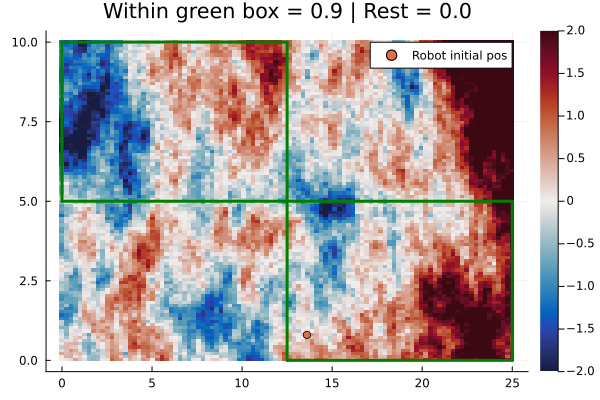

In [21]:
plot()
heatmap(env_data.X, env_data.Y, env_data.W', cmap = :balance; plottype=:wx)
scatter!(first.(x0s), last.(x0s), label = "Robot initial pos")
plot!(clims=(-2,2))
# Define the range for x
x1 = 0:0.1:12.5
x3 = 0:0.1:12.5
y2 = 5.0:0.1:10.0
y4 = 5.0:0.1:10.0
x5 = 12.5:0.1:25
y7 = 0:0.1:5.0
# Define the constant y
y1 = 5 .* ones(length(x1))
y3 = 10 .* ones(length(x1))
x2 = 12.5 .* ones(length(y2))
x4 = 0.0 .* ones(length(y2))
y5 = 0.0 .* ones(length(x5))
y6 = 5.0 .* ones(length(x5))
x7 = 12.5 .* ones(length(y7))
x8 = 25 .* ones(length(y7))
                    
# Plot the line
# Top left box
plot!(x1, y1, label="", lw=3, color = "green")
plot!(x2, y2, label="", lw=3, color = "green")
plot!(x3, y3, label="", lw=3, color = "green")
plot!(x4, y4, label="", lw=3 ,color = "green")

# Bottom right box 
plot!(x5, y5, label="", lw=3, color = "green")
plot!(x5, y6, label="", lw=3, color = "green")
plot!(x7, y7, label="", lw=3, color = "green")
plot!(x8, y7, label="", lw=3 ,color = "green")

title!("Within green box = 0.9 | Rest = 0.0")

In [22]:
ΔT = 5.0 / 60.0 # seconds
Tend = 1.0 # hours 
ts = 0.0:(ΔT):(Tend * 60)

0.0:0.08333333333333333:60.0

In [23]:
function Cfun(p, x)
    return kern(x, p)^2 / kern(p, p)
end
function Rfun(p, x)
    return (kern(x,x) - kern(x, p)^2 / kern(p, p) + 0.5^2)/(ΔT)
end


S(p, x)  = Cfun(p, x)^2 / Rfun(p, x)
DxS(p, x) = ForwardDiff.gradient(xx-> S(p, xx), x)

DxS (generic function with 1 method)

In [24]:
using DifferentialEquations
using ForwardDiff

function clarity_prediction(t, q0, C, R, Q)

    k = C / sqrt(Q * R)
    
    q∞ = k / (1 + k)

    γ1 = q∞ - q0
    γ2 = γ1 * (k-1)
    γ3 = (k-1) * q0 - k

    return q∞ * ( 1 + 2 * γ1 / (γ2 + γ3 * exp(2 * k * Q * t)))
end

    
function clarity_time(q0, qf, C, R, Q; tmax=10.0)
    
    println("q0: $(q0)")
    println("qf: $(qf)")
    println("C: $(C)")
    println("R: $(R)")
    println("Q: $(Q)")
    
    if q0 >= qf
        return 0.0
    end

    k = C / sqrt(Q * R)
    println("k: $(k)")
    
    q∞ = k / (1 + k)
    println("q∞: $(q∞)")
    γ1 = q∞ - q0
    γ2 = γ1 * (k-1)
    γ3 = (k-1) * q0 - k

    
        
    if qf >= q∞
        return tmax
    end

    t = log((2*q∞*γ1 - qf*γ2 + q∞*γ2)/((qf - q∞)*γ3))/(2*k*Q)
    println("t: $(t)")

    return min(t, tmax)
end

C = 1.0
R = 0.5
Q = 0.0
Clarity_decay(u,p,t) = (C^2 / R) * (1-u)^2 - Q * u^2
k = (C^2 / R)
# q(t) = ((-k * t * q_0) + (k * t * q_0)) / ((-k * t * q_0) + (k * t) + 1)

function Clarity_delta_t(current_clarity, target_clarity)
    delta_t = (target_clarity - current_clarity) / ((target_clarity - 1) * k * (current_clarity - 1))
    return delta_t
end

function Clarity_delta_new(current_clarity, target_clarity)
    den = -target_clarity*k + k*current_clarity*target_clarity + k - k*current_clarity
    return delta_t = (target_clarity - current_clarity) / den
end


function Forward_Simulate_Clarity(current_clarity, target_clarity; fn::Function = Clarity)
    """
    Forward simulate for maximum 10 seconds
    Here for now I only consider the spatiostatic environment 
    """    
    tspan = (0.0, 10.0) # 10 is just chosen to be a huge value for this problem
    u0 = current_clarity
    prob = ODEProblem(fn, u0, tspan)
    condition(u, t, integrator) = u ≥ target_clarity
    affect!(integrator) = terminate!(integrator)
    cb = DiscreteCallback(condition, affect!)
    sol = solve(prob, Tsit5(), callback = cb);
    return sol.t[end]
    
end

Forward_Simulate_Clarity (generic function with 1 method)

In [25]:
# Qp  = mean(σ_t.^2) # diagm(vec(σ_t .^2 * fuse_measurements_every_ΔT ))

In [26]:
 δt = Forward_Simulate_Clarity(0.1, 0.2; fn = Clarity_decay)

0.13507106021430565

In [27]:
 δt = Clarity_delta_t(0.1, 0.2)

0.06944444444444443

In [28]:
 δt = Clarity_delta_new(0.1, 0.2)

0.06944444444444443

In [29]:
using LinearAlgebra, StatsBase

function ergo_controller3(t, xs; 
        ergo_grid,
        ergo_q_map,
        traj,
        umax=30.0 * 60 / 1000,
        ΔT,
        kwargs...
        )

    target_q = 0.9 ; # * ones(size(ergo_q_map))

    target_spatial_dist = zeros(size(ergo_q_map))

    Qp  = mean(σ_t.^2) # diagm(vec(σ_t .^2 * fuse_measurements_every_ΔT ))

#     C_ = Cfun(0,0)
#     R_ = Rfun(0,0)
    
    # Only explore the right-hand side of the environment
    for i in CartesianIndices(target_spatial_dist)
        if (i[1] >= 50 && i[2] <= 200) && (i[1] <= 200 && i[2] >= 50)
            if target_q > ergo_q_map[i]
                target_spatial_dist[i] = Clarity_delta_new(ergo_q_map[i], target_q)
            else
                target_spatial_dist[i] = 0.0
            end
        else
            target_spatial_dist[i] = 0.0
        end
    end
        
    u = [ErgodicController.controller_single_integrator(ergo_grid, x, traj, target_spatial_dist; umax=umax, do_boundary_correction=false) for x in xs]
    return u

end

ergo_controllers3 = [ergo_controller3 for i=1:length(x0s)]

1-element Vector{typeof(ergo_controller3)}:
 ergo_controller3 (generic function with 1 method)

In [84]:
ΔT = 5.0/60.0 # minutes
T_begin = 9.0; # hours
T_end = 11.0; # hours 
ts = T_begin*60:(ΔT):T_end*60
fuse_measurements_every_ΔT = 5.0 # minutes
recompute_controller_every_ΔT = 5.0 / 60.0 # minutes
σ_t = zeros(63, 26);

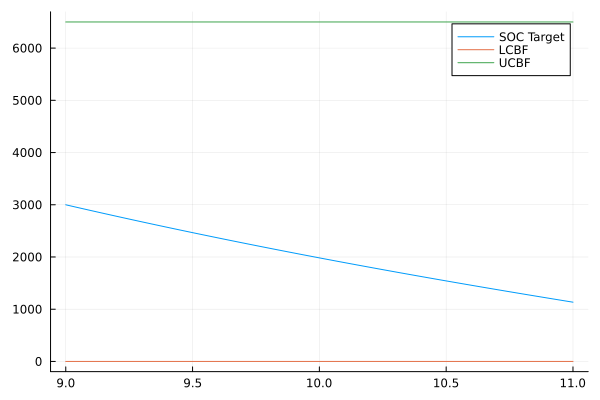

In [85]:
# Generate SOC_Target Profile
soc_begin = 3000
soc_end = 1250
lcbf = SoCController.compute_lcbf(ts/60, ΔT/60);
ucbf = SoCController.compute_ucbf(ts/60, ΔT/60);
soc_target = SoCController.generate_SOC_target(lcbf, ucbf,  soc_begin, soc_end, ts/60, ΔT/60);
plot(ts/60, soc_target, label="SOC Target")
plot!(ts/60, lcbf, label="LCBF")
plot!(ts/60,ucbf, label="UCBF")

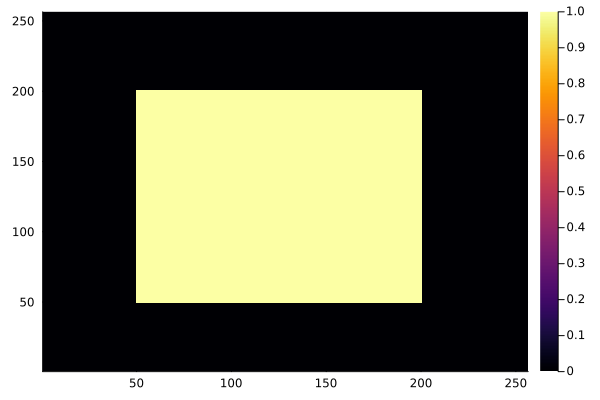

In [86]:
# Test the code 

w_hat = NGPKF.initialize(ngpkf_grid)
# Initial w_hat
# Based on w_hat, initialize current clarity
# 
# σ = KF.σ(w_hat)
q_map = NGPKF.clarity_map(ngpkf_grid, w_hat)

ergo_grid = SimulatorSpatial.ErgoGrid(ngpkf_grid, (256, 256))
ergo_q_map = SimulatorSpatial.ngpkf_to_ergo(ngpkf_grid, ergo_grid, q_map);

target_spatial_dist = zeros(size(ergo_q_map));

# Only assign target clarity  


for i in CartesianIndices(target_spatial_dist)
    if (i[1] >= 50 && i[2] <= 200) && (i[1] <= 200 && i[2] >= 50)
        target_spatial_dist[i] = 1.0
    end
    
    #     if target_q > ergo_q_map[i]
#         target_spatial_dist[i] = Forward_Simulate_Clarity(ergo_q_map[i], target_q; fn = Clarity_decay)
#     else
#         target_spatial_dist[i] = 0.0
#     end
# #         target_spatial_dist[i] = clarity_time(ergo_q_map[i], target_q, C_, R_, Qp)
end

heatmap(target_spatial_dist')

In [87]:
@time res_ergo =  SimulatorSpatial.simulate_spatial_w_speed(ts, x0s, soc_begin, ergo_controller3, soc_target; 
    ngpkf_grid=ngpkf_grid, 
    EnvDataSpatial=env_data, 
    σ_meas = 0.5,
    # σ_process= 0.075 * fuse_measurements_every_ΔT,
    Q_process = diagm(vec(σ_t .^2 * fuse_measurements_every_ΔT )) , 
    fuse_measurements_every_ΔT = fuse_measurements_every_ΔT, 
    recompute_controller_every_ΔT = recompute_controller_every_ΔT)

Progress:   0%|                                         |  ETA: N/A
Progress:   1%|▎                                        |  ETA: 0:00:24
Progress:   1%|▌                                        |  ETA: 0:00:19
Progress:   2%|▋                                        |  ETA: 0:00:19
Progress:   2%|▉                                        |  ETA: 0:00:19
Progress:   3%|█▏                                       |  ETA: 0:00:19
Progress:   3%|█▍                                       |  ETA: 0:00:19


Inside prediction of NGP


Progress:   4%|█▋                                       |  ETA: 0:00:18
Progress:   4%|█▉                                       |  ETA: 0:00:29
Progress:   5%|██                                       |  ETA: 0:00:27
Progress:   6%|██▎                                      |  ETA: 0:00:26
Progress:   6%|██▌                                      |  ETA: 0:00:25
Progress:   7%|██▊                                      |  ETA: 0:00:25
Progress:   7%|███                                      |  ETA: 0:00:24
Progress:   8%|███▎                                     |  ETA: 0:00:24


Inside prediction of NGP


Progress:   8%|███▍                                     |  ETA: 0:00:24
Progress:   9%|███▋                                     |  ETA: 0:00:29
Progress:   9%|███▉                                     |  ETA: 0:00:28
Progress:  10%|████▏                                    |  ETA: 0:00:27
Progress:  11%|████▍                                    |  ETA: 0:00:27
Progress:  11%|████▌                                    |  ETA: 0:00:26
Progress:  12%|████▊                                    |  ETA: 0:00:26


...

Progress:  91%|█████████████████████████████████████▍   |  ETA: 0:00:03
Progress:  92%|█████████████████████████████████████▋   |  ETA: 0:00:03
Progress:  92%|█████████████████████████████████████▊   |  ETA: 0:00:03
Progress:  93%|██████████████████████████████████████   |  ETA: 0:00:02
Progress:  93%|██████████████████████████████████████▎  |  ETA: 0:00:02
Progress:  94%|██████████████████████████████████████▌  |  ETA: 0:00:02
Progress:  94%|██████████████████████████████████████▊  |  ETA: 0:00:02
Progress:  95%|███████████████████████████████████████  |  ETA: 0:00:02


Inside prediction of NGP


Progress:  96%|███████████████████████████████████████▏ |  ETA: 0:00:01
Progress:  96%|███████████████████████████████████████▍ |  ETA: 0:00:01
Progress:  97%|███████████████████████████████████████▋ |  ETA: 0:00:01
Progress:  97%|███████████████████████████████████████▉ |  ETA: 0:00:01
Progress:  98%|████████████████████████████████████████▏|  ETA: 0:00:01
Progress:  98%|████████████████████████████████████████▍|  ETA: 0:00:01
Progress:  99%|████████████████████████████████████████▌|  ETA: 0:00:00
Progress:  99%|████████████████████████████████████████▊|  ETA: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:32
Progress: 100%|█████████████████████████████████████████| Time: 0:00:32


 32.742142 seconds (204.26 M allocations: 13.617 GiB, 5.45% gc time, 0.05% compilation time)


Main.SimulatorSpatial.SimResult{StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}, Vector{Vector{SVector{2, Float64}}}, Vector{Vector{SVector{2, Float64}}}, Vector{Float64}, Vector{Main.SimulatorSpatial.MeasurementSpatial{Float64, SVector{2, Float64}, Float64}}, Vector{Float64}, Vector{Main.KF.KFState{Vector{Float64}, UpperTriangular{Float64, Matrix{Float64}}}}, Vector{Matrix{Float64}}}(540.0:0.08333333333333333:660.0, Vector{SVector{2, Float64}}[[[13.6, 0.8]], [[13.600357785176925, 0.8003872004770939]], [[13.601809963139171, 0.8019733344279011]], [[13.604232098368689, 0.8047196693870651]], [[13.607678265226856, 0.8088836285891627]], [[13.612101354442196, 0.814758012061753]], [[13.617339297010014, 0.8226916602465753]], [[13.622229650159486, 0.8335022228058107]], [[13.626864872283765, 0.8471661198843686]], [[13.63085549529087, 0.8638937930483701]]  …  [[19.851635747679392, 7.684539053843843]], [[19.678475483527038, 7.769582366551317]], [[19.6309333

In [112]:
plot()
heatmap(env_data.X, env_data.Y, env_data.W', cmap = :balance; plottype=:wx, clims=(-2, 2))
for i=1:length(x0s)
    x = [r[i][1] for r in res_ergo.xs]
    y = [r[i][2] for r in res_ergo.xs]
    plot!(x,y, linewidth=3, color=:black, label = "")
end
plot!()

# Define the range for x
x1 = 5:0.1:20
x3 = 5:0.1:20
y2 = 2.0:0.1:8.0

# Define the constant y
y1 = 2 .* ones(length(x1))
y3 = 8 .* ones(length(x1))
x2 = 5 .* ones(length(y2))
x4 = 20 .* ones(length(y2))
                    
# Plot the line
# Top left box
plot!(x1, y1, label="", lw=3, color = "green")
plot!(x2, y2, label="", lw=3, color = "green")
plot!(x3, y3, label="", lw=3, color = "green")
plot!(x4, y2, label="", lw=3 ,color = "green")


title!("Within green box = 0.9 | Rest = 0.0")
savefig("results/integrated_soc/trajectory.png")

"/home/kmgovind/Documents/adaptive-ocean-exploration-sim/results/integrated_soc/trajectory.png"

In [89]:
u1 = Float64[]
u2 = Float64[]
speed = Float64[]

for i=1:length(res_ergo.us)
    push!(u1, res_ergo.us[i][1][1])
    push!(u2, res_ergo.us[i][1][2])
    push!(speed, norm(res_ergo.us[i][1]))
end

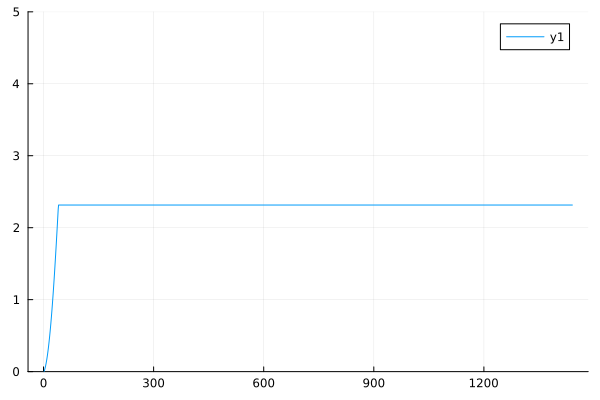

In [90]:
plot(speed)
ylims!(0., 5.0)

# length(speed)
# interpolated_times = range(0, stop=170, length=2041)
# interpolated_speeds = [v_itp(t) for t in interpolated_times]

In [111]:
# gr()
# plot(interpolated_times, interpolated_speeds, lw=2.0, label="Desired speed profile")
plot(interpolated_times, speed, linestyle=:dash, lw=2.0, label ="Ergodic speed profile")
ylims!(0., 5.0)
xlabel!("Time [min]")
ylabel!("Speed [km/min]")

UndefVarError: UndefVarError: `interpolated_times` not defined

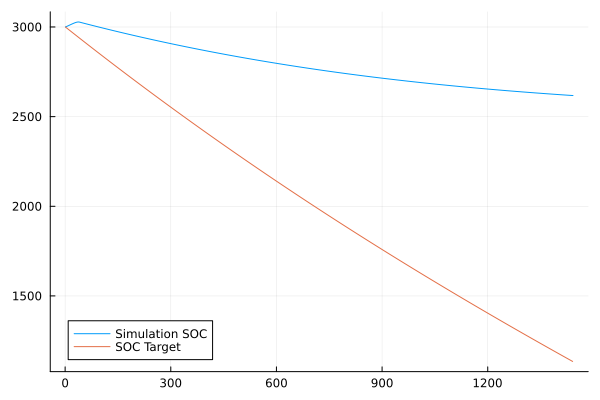

In [117]:
plot(res_ergo.bs, label="Simulation SOC")
plot!(soc_target, label="SOC Target")
# savefig("results/integrated_soc/soc.png")

[ Info: Saved animation to /tmp/jl_sbElobk1gb.gif


Plots.AnimatedGif("/tmp/jl_sbElobk1gb.gif")
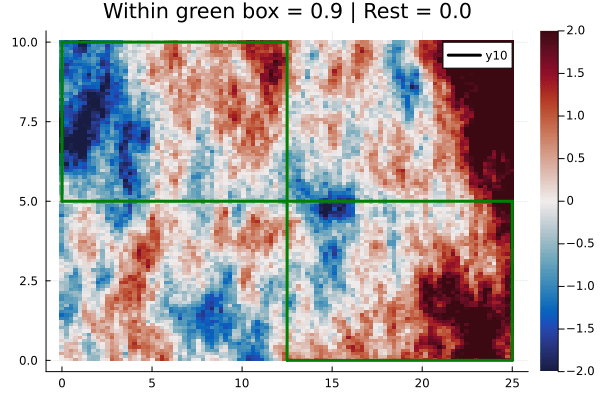

In [93]:
gr()
@gif for n = Int.(floor.(range(1, length(res_ergo.xs), length=420)))
    plot()
    heatmap(env_data.X, env_data.Y, env_data.W', cmap = :balance; plottype=:wx, clims=(-2, 2))

    # Define the range for x
    x1 = 0:0.1:12.5
    x3 = 0:0.1:12.5
    y2 = 5.0:0.1:10.0
    y4 = 5.0:0.1:10.0
    x5 = 12.5:0.1:25
    y7 = 0:0.1:5.0
    # Define the constant y
    y1 = 5 .* ones(length(x1))
    y3 = 10 .* ones(length(x1))
    x2 = 12.5 .* ones(length(y2))
    x4 = 0.0 .* ones(length(y2))
    y5 = 0.0 .* ones(length(x5))
    y6 = 5.0 .* ones(length(x5))
    x7 = 12.5 .* ones(length(y7))
    x8 = 25 .* ones(length(y7))

    # Plot the line
    # Top left box
    plot!(x1, y1, label="", lw=3, color = "green")
    plot!(x2, y2, label="", lw=3, color = "green")
    plot!(x3, y3, label="", lw=3, color = "green")
    plot!(x4, y4, label="", lw=3 ,color = "green")

    # Bottom right box 
    plot!(x5, y5, label="", lw=3, color = "green")
    plot!(x5, y6, label="", lw=3, color = "green")
    plot!(x7, y7, label="", lw=3, color = "green")
    plot!(x8, y7, label="", lw=3 ,color = "green")

    for i=1:length(x0s)
        x = [r[i][1] for r in res_ergo.xs[1:n]]
        y = [r[i][2] for r in res_ergo.xs[1:n]]
        plot!(x, y, linewidth=3, color=:black)
    end
    plot!()
    title!("Within green box = 0.9 | Rest = 0.0")
end

# # Plot line 
# # Define the constant y
# # Define the range for x
# x1 = 0:0.1:25

# # Define the constant y
# y1 = 5 .* ones(length(x1))

# # Plot the line
# plot!(x1, y1, label="", lw=5)


In [94]:
size(res_ergo.w_hats)

(24,)

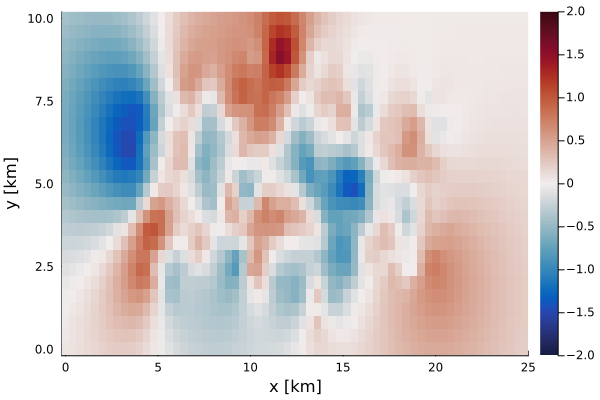

In [95]:
gr()

p2 = heatmap(ngpkf_grid, res_ergo.w_hats[end],colormap=:balance, clims=(-2,2))


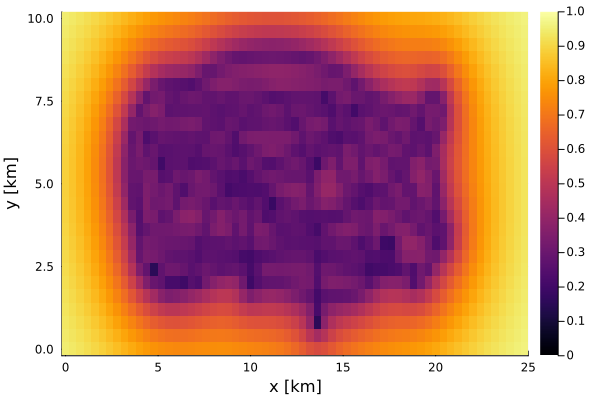

In [96]:
p2 = heatmap(ngpkf_grid, res_ergo.w_hats[end], clims=(0, 1.0), plotstd=true)
# for i=1:length(x0s)
#     x = [r[i][1] for r in res_ergo.xs]
#     y = [r[i][2] for r in res_ergo.xs]
#     plot!(x, y, linewidth=3)
# end
plot!()

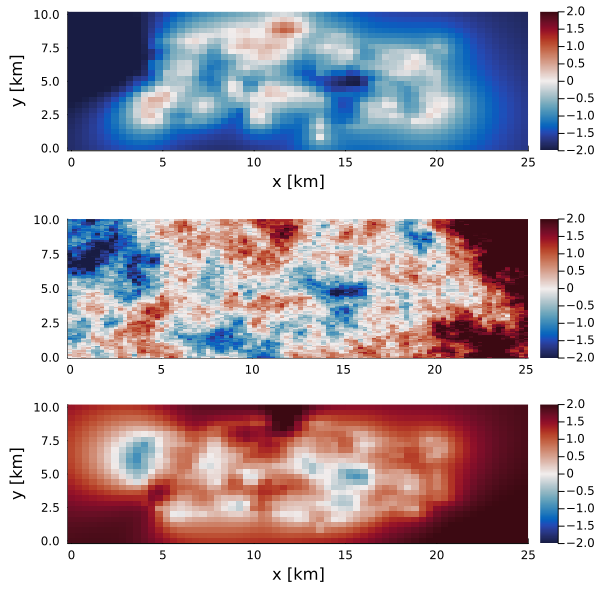

In [97]:
gr()

p1 = heatmap(ngpkf_grid, res_ergo.w_hats[end],colormap=:balance, clims=(-2,2), plot_min=true)
p2 = heatmap(ngpkf_grid, res_ergo.w_hats[end],colormap=:balance, clims=(-2,2), plot_max=true)
p3 = heatmap(env_data.X, env_data.Y, env_data.W', cmap = :balance; plottype=:wx, clims=(-2, 2))
    
plot(p1, p3, p2, layout = (@layout [a;b; c]), size=[600, 600])

In [98]:
# Compute RMSE

Nx, Ny = length(ngpkf_grid.xs), length(ngpkf_grid.ys)

M = reshape(KF.μ(res_ergo.w_hats[end]), Nx, Ny)
heatmap(M',colormap=:balance, clims=(-2,2) )
x_new = 0:0.4:25
y_new = 0:0.4:10
Data_sampled = [env_data.itp_w(xi, yi) for yi in y_new, xi in x_new]
Diff = M' .- Data_sampled
rmse = sqrt(mean(Diff .^ 2))

0.8292577860702167

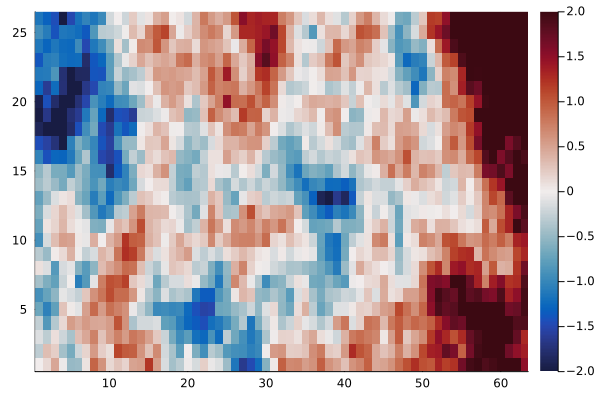

In [99]:
heatmap(Data_sampled,colormap=:balance, clims=(-2,2))

In [100]:
# Compute Precision

σ_prec = KF.σ(res_ergo.w_hats[end])
M_prec = reshape(σ_prec, Nx, Ny)
precision = sum(M_prec)/length(M_prec)

0.5328819389734886

In [105]:
using LinearAlgebra, StatsBase

mean_deficit_1 = [mean(map( c -> max(0, 1.0 - c), q )) for q in res_ergo.ergo_q_maps]
mean_deficit_1[end]

0.21673531625580528

In [106]:
ts = range(1, 100, 20)
time = collect(ts)

20-element Vector{Float64}:
   1.0
   6.2105263157894735
  11.421052631578947
  16.63157894736842
  21.842105263157894
  27.05263157894737
  32.26315789473684
  37.473684210526315
  42.68421052631579
  47.89473684210526
  53.10526315789474
  58.31578947368421
  63.526315789473685
  68.73684210526316
  73.94736842105263
  79.15789473684211
  84.36842105263158
  89.57894736842105
  94.78947368421052
 100.0

In [107]:
# plot(res_ergo.w_hat_ts, mean_deficit_1, marker=:dot)
gr()
plot()
plot!(time, mean_deficit_1, marker=:dot)
ylabel!("Clarity Deficit[0,1]")
xlabel!("Time [min]")
ylims!(0., 0.6)

┌ Warning: Keyword argument markerstrokestyle not supported with
│ Plots.GRBackend(). Choose from: annotationcolor, annotationfontfamily,
│ annotationfontsize, annotationhalign, annotationrotation, annotations,
│ annotationvalign, arrow, aspectratio, axis, backgroundcolor,
│ backgroundcolorinside, backgroundcoloroutside, backgroundcolorsubplot,
│ barwidth, bins, bottommargin, camera, clims, colorpalette, colorbar,
│ colorbarentry, colorbarscale, colorbartitle, colorbartitlefont,
│ colorbartitlefontcolor, colorbartitlefontrotation, colorbartitlefontsize,
│ connections, contourlabels, discretevalues, fill, fillz, fillalpha,
│ fillcolor, fillrange, fillstyle, flip, fontfamily, fontfamilysubplot,
│ foregroundcolor, foregroundcoloraxis, foregroundcolorborder,
│ foregroundcolorgrid, foregroundcolorsubplot, foregroundcolortext,
│ formatter, framestyle, grid, gridalpha, gridlinewidth, gridstyle, group,
│ guide, guidefont, guidefontcolor, guidefontfamily, guidefonthalign,
│ guidefontrotation, g